# Évaluation du Clustering avec K-Means et Autoencodeur (ANN) via Silhouette Score et Davies-Bouldin Index


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

# 1. Chargement et Standardisation


In [3]:
df = pd.read_csv('/content/sample_data/Mall_Customers.csv')
X = df.iloc[:, [3, 4]].values
X_scaled = StandardScaler().fit_transform(X)
X_tensor = torch.FloatTensor(X_scaled)

# 2. Architecture de l'ANN (Auto-encodeur)

In [4]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 2))
        self.decoder = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 2))
    def forward(self, x):
        latent = self.encoder(x)
        return latent, self.decoder(latent)

### Entraînement de l'ANN


In [5]:
model = Autoencoder()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
for epoch in range(100):
    latent, rec = model(X_tensor)
    loss = nn.MSELoss()(rec, X_tensor)
    optimizer.zero_grad(); loss.backward(); optimizer.step()



### Extraction des caractéristiques (Espace Latent)

In [6]:
X_latent = model.encoder(X_tensor).detach().numpy()

# 3. Calcul des métriques sur les données transformées par ANN

In [7]:
sil_scores, db_scores = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_latent)
    sil_scores.append(silhouette_score(X_latent, labels))
    db_scores.append(davies_bouldin_score(X_latent, labels))

# 4. Visualisation

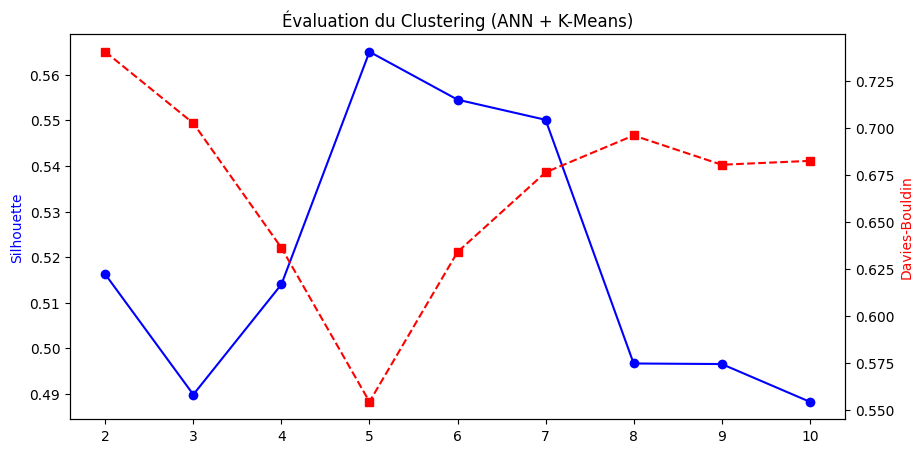

In [8]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(k_range, sil_scores, 'b-o', label='Silhouette (Max)'); ax1.set_ylabel('Silhouette', color='b')
ax2 = ax1.twinx()
ax2.plot(k_range, db_scores, 'r--s', label='DB Index (Min)'); ax2.set_ylabel('Davies-Bouldin', color='r')
plt.title('Évaluation du Clustering (ANN + K-Means)')
plt.show()

### Interprétation des Métriques de Clustering

Observons les scores pour trouver le nombre de clusters optimal:

*   **Silhouette Score (Max)**: En regardant le graphique, le score de Silhouette atteint son maximum à `k = 5` avec une valeur d'environ `0.55`.
*   **Davies-Bouldin Index (Min)**: L'indice de Davies-Bouldin est le plus bas à `k = 5` avec une valeur d'environ `0.55`.

**Conclusion**:
Les deux critères convergent vers k = 5 comme nombre optimal de clusters.
Un score de Silhouette autour de 0.57 reflète une structure de clusters raisonnablement bonne, le Davies-Bouldin bas confirme une bonne  séparation satisfaisante dans l’espace latent produit par l’auto-encodeur (ANN).